In [1]:
import numpy as np
import matplotlib.pylab as plt
import matplotlib as mpl
mpl.rcParams['font.size'] = 16

imagepath = "C:\\Users\\User\\Documents\\Documents\\University\\Master_SU\\Year_1\\IIB\\CompAstro\\Projects\\Project3\\Plots\\"

In [2]:
def initial_data(x,IC):
    """Returns the initial density for a set of x, with either a tophat shaped density
    (IC: "tophat"), a Gaussian density (IC: "gaussian") or a user chosen density 
    (IC: "users_choice").
    x : set of points in space
    IC : type of initial density takes "tophat", "gaussian" or "users_choice"."""
    nzones = len(x)
    rho = np.zeros(nzones)
    if IC=='tophat':
        #create tophat initial data
        rho[:] = 1e3    #no he wants to make an actual top hat _|-|_
    elif IC=='gaussian':
        #create gaussian initial data
        sig = 0.2
        x0 = 0.5
        rho[:] = np.exp(-(((x-x0)/sig)**2))
    elif IC=='users_choice':
        #create your own initial data
        rho[:] = np.array(input("Initial density ? "))

    else:
        print("Must define initial data")

    return rho

def evolve_advection_problem(nzones=50,xmin=0.0,xmax=1.0,speed=1.0,C=0.25,tend=1.0,IC='tophat'):
    #construct grid, dx is the grid spacing, set by the xmin and xmax and the number of zones
    dx = (xmax-xmin)/nzones
    #set the x array, we want the x value to be the zone center coordinate, so shift the array from linspace by dx/2
    x = np.linspace(xmin,xmax,nzones,endpoint=False) + dx/2

    #set initial conditions
    rho = initial_data(x, IC)

    #make a copy of ID to return
    rho0 = rho.copy()
    
    #arrays for the flux through the m+1/2 (Fmphalf) and the m-1/2 (Fmmhalf) interfaces
    Fmphalf = np.zeros(nzones)
    Fmmhalf = np.zeros(nzones)

    time=0.0
    while time<tend:
        rhon = rho.copy()
        dt = C*dx/np.abs(speed)
        #prevect time from exceeding tend
        if time + dt > tend:
            dt = tend-time
            
        #flux though m+1/2 interface
        #remember to consider boundary conditions
        #feel free to speed it up by doing things directly with the vector, not so critical for 1D
        #this is for clarity

        if speed>0:
            Fmphalf[:] = speed*rhon         #don't forget the speed here
            Fmmhalf[1:] = speed*rhon[:-1]
            Fmmhalf[0] = speed*rhon[-1]

        else:
            Fmphalf[:-1] = speed*rhon[1:]
            Fmphalf[-1] = speed*rhon[0]
            Fmmhalf[:] = speed*rhon

        #advance the density field forward in time by dt
        rho[:] = ((Fmmhalf-Fmphalf)/dx) * dt + rhon

        #advance the time variable, and loop
        time = time + dt

    return x, rho, rho0

50 0.11327746789104416
100 0.06637529475103313
200 0.036482781807153766
400 0.019220684212109353
800 0.009879270555746373
1600 0.005010370978724011


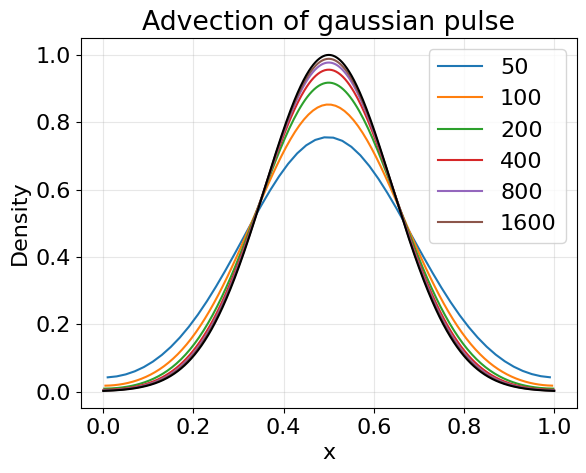

In [3]:
fig, ax = plt.subplots(1,1)  

Ns = [50,100,200,400,800,1600]
error = np.zeros(len(Ns)*2).reshape(len(Ns),2)
count=0
for i in Ns:
    x,rho,rho0 = evolve_advection_problem(nzones=i,xmin=0.0,xmax=1.0,speed=1.0,C=0.25,tend=1.0,IC='gaussian')
    ax.plot(x,rho, label=f"{i}")
    deltax = x[1]-x[0]
    L2norm = np.sqrt(np.sum((rho[:]-rho0[:])**2, axis=0)/i)
    print(i,L2norm)
    error[count,0] = i
    error[count,1] = L2norm
    count += 1  

ax.plot(x, rho0, 'k')
ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.set_title(f"Advection of gaussian pulse")
ax.grid(alpha=0.3)
ax.legend()
fig.savefig(imagepath+"advection_ex1.pdf", dpi = 300, bbox_inches="tight")

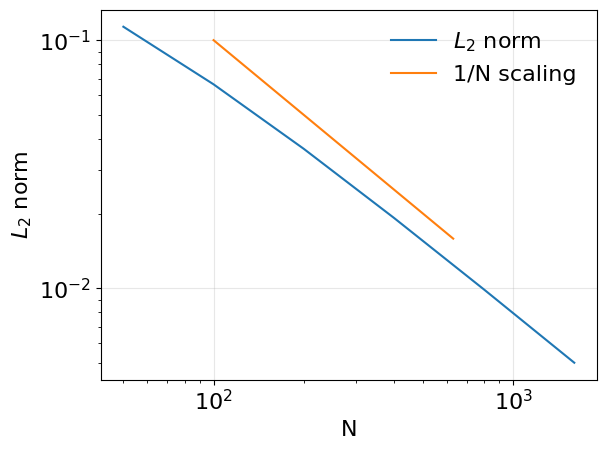

In [4]:
fig2, ax1 = plt.subplots(1,1)
ax1.plot(error.T[0],error.T[1],label="$L_2$ norm")
x2=np.logspace(2,2.8)
ax1.plot(x2,10/x2,label="1/N scaling")
ax1.legend(frameon=False)
ax1.set_xlabel("N")
ax1.set_ylabel("$L_2$ norm")
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.grid(alpha=0.3)
fig2.savefig(imagepath+"normL2_ex1.pdf", dpi = 300, bbox_inches="tight")